In [5]:
# 1: Environment Setup, Global Config & Seed Initialization

# Import core system and standard utilities
import os
import random
import shutil
from pathlib import Path

# Import data processing and scientific computing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Deep Learning framework components
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# Import metrics and evaluation utilities
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Set global deterministic random seed
GLOBAL_SEED = 42
keras.utils.set_random_seed(GLOBAL_SEED)

# Enable deterministic operations where supported by hardware backend
try:
    tf.config.experimental.enable_op_determinism()
    print("[INFO] Deterministic TensorFlow operations enabled.")
except Exception as err:
    print(f"[WARNING] Could not enable deterministic operations: {err}")

# Configure GPU memory growth dynamically
physical_gpus = tf.config.list_physical_devices("GPU")
if physical_gpus:
    for gpu_device in physical_gpus:
        tf.config.experimental.set_memory_growth(gpu_device, True)
    # Enable mixed precision computation for faster training and lower VRAM usage
    keras.mixed_precision.set_global_policy("mixed_float16")
    print(f"[INFO] GPUs detected: {len(physical_gpus)} | Mixed precision: mixed_float16 enabled.")
else:
    print("[WARNING] No GPU detected. Execution will proceed on CPU.")

# Directory hierarchy definition based on project structure
DATASET_ROOT = Path("17_flowers")
TRAIN_DIR = DATASET_ROOT / "train"
ORIGINAL_VALID_DIR = DATASET_ROOT / "validation"

# Target directories for programmatic split
SPLIT_ROOT = DATASET_ROOT / "splits"
VALID_SPLIT_DIR = SPLIT_ROOT / "valid"
TEST_SPLIT_DIR = SPLIT_ROOT / "test"
SPLIT_MANIFEST_PATH = SPLIT_ROOT / "split_manifest.csv"

# Artifact and experiment tracking paths
ARTIFACTS_DIR = Path("artifacts")
CHECKPOINT_DIR = ARTIFACTS_DIR / "checkpoints"
METRICS_DIR = ARTIFACTS_DIR / "metrics"
PLOTS_DIR = ARTIFACTS_DIR / "plots"

for directory in [CHECKPOINT_DIR, METRICS_DIR, PLOTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Hyperparameters & Constants
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)
BATCH_SIZE = 32
NUM_CLASSES = 17
TEST_SPLIT_RATIO = 0.50  # 50% of validation pool goes to test, 50% remains as validation
AUTOTUNE = tf.data.AUTOTUNE

print(f"[INFO] Environment ready. Target input resolution: {IMG_SIZE}")


[INFO] Deterministic TensorFlow operations enabled.
[WARNING] No GPU detected. Execution will proceed on CPU.
[INFO] Environment ready. Target input resolution: (224, 224)


In [6]:
# 2: Automated Stratified Split Generation (Validation --> valid & test)

SUPPORTED_IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

def build_stratified_test_split(
    source_val_dir: Path,
    target_valid_dir: Path,
    target_test_dir: Path,
    manifest_filepath: Path,
    test_ratio: float = 0.50,
    seed: int = 42,
    force_rebuild: bool = False
) -> pd.DataFrame:
    """
    Executes a reproducible, class-stratified split from the validation directory
    into separate validation and test sets without modifying the original source.
    """
    if manifest_filepath.exists() and not force_rebuild:
        print("[INFO] Existing split manifest detected. Loading existing configuration...")
        return pd.read_csv(manifest_filepath)

    print("[INFO] Constructing deterministic validation/test split partitions...")

    if target_valid_dir.exists():
        shutil.rmtree(target_valid_dir)
    if target_test_dir.exists():
        shutil.rmtree(target_test_dir)

    target_valid_dir.mkdir(parents=True, exist_ok=True)
    target_test_dir.mkdir(parents=True, exist_ok=True)

    rng = random.Random(seed)
    manifest_records = []
    class_directories = sorted([d for d in source_val_dir.iterdir() if d.is_dir()])

    for class_folder in class_directories:
        class_name = class_folder.name
        (target_valid_dir / class_name).mkdir(parents=True, exist_ok=True)
        (target_test_dir / class_name).mkdir(parents=True, exist_ok=True)

        image_files = sorted([
            file_path for file_path in class_folder.iterdir()
            if file_path.is_file() and file_path.suffix.lower() in SUPPORTED_IMAGE_EXTENSIONS
        ])

        if len(image_files) < 2:
            raise ValueError(f"Class '{class_name}' contains insufficient samples ({len(image_files)}) for splitting.")

        # Shuffle deterministically per class
        rng.shuffle(image_files)

        test_sample_count = max(1, int(round(len(image_files) * test_ratio)))
        test_sample_count = min(test_sample_count, len(image_files) - 1)

        test_partition = image_files[:test_sample_count]
        valid_partition = image_files[test_sample_count:]

        for img in valid_partition:
            dest = target_valid_dir / class_name / img.name
            shutil.copy2(img, dest)
            manifest_records.append({
                "filename": img.name,
                "class_name": class_name,
                "split": "valid",
                "original_path": str(img),
                "allocated_path": str(dest)
            })

        for img in test_partition:
            dest = target_test_dir / class_name / img.name
            shutil.copy2(img, dest)
            manifest_records.append({
                "filename": img.name,
                "class_name": class_name,
                "split": "test",
                "original_path": str(img),
                "allocated_path": str(dest)
            })

    manifest_df = pd.DataFrame(manifest_records)
    manifest_df.to_csv(manifest_filepath, index=False)
    print(f"[INFO] Stratified splitting complete. Manifest exported to: {manifest_filepath}")
    return manifest_df

# Execute partition generation
split_df = build_stratified_test_split(
    source_val_dir=ORIGINAL_VALID_DIR,
    target_valid_dir=VALID_SPLIT_DIR,
    target_test_dir=TEST_SPLIT_DIR,
    manifest_filepath=SPLIT_MANIFEST_PATH,
    test_ratio=TEST_SPLIT_RATIO,
    seed=GLOBAL_SEED,
    force_rebuild=False
)

# Display class-wise breakdown across newly generated splits
summary_pivot = split_df.pivot_table(index="class_name", columns="split", values="filename", aggfunc="count", fill_value=0)
display(summary_pivot)


[INFO] Existing split manifest detected. Loading existing configuration...


split,test,valid
class_name,,
bluebell,5,5
buttercup,5,5
colts_foot,5,5
cowslip,5,5
crocus,5,5
daffodil,5,5
daisy,5,5
dandelion,5,5
fritillary,5,5


In [7]:
# 3: Building Optimized tf.data Input Pipelines

# Construct TensorFlow Dataset instances directly from directory structures
train_dataset = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=GLOBAL_SEED,
)

valid_dataset = keras.utils.image_dataset_from_directory(
    VALID_SPLIT_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_dataset = keras.utils.image_dataset_from_directory(
    TEST_SPLIT_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Extract ground-truth class label names
CLASS_NAMES = train_dataset.class_names
assert len(CLASS_NAMES) == NUM_CLASSES, f"Mismatch in expected class count ({NUM_CLASSES}) vs found ({len(CLASS_NAMES)})"

# Apply memory caching, deterministic shuffling, and background prefetching
train_ds = (
    train_dataset
    .cache()
    .shuffle(buffer_size=1000, seed=GLOBAL_SEED, reshuffle_each_iteration=True)
    .prefetch(buffer_size=AUTOTUNE)
)

valid_ds = valid_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print(f"[INFO] Successfully initialized data pipelines for {len(CLASS_NAMES)} target classes.")
print(f"[INFO] Class categories: {CLASS_NAMES}")


Found 1190 files belonging to 17 classes.
Found 85 files belonging to 17 classes.
Found 85 files belonging to 17 classes.
[INFO] Successfully initialized data pipelines for 17 target classes.
[INFO] Class categories: ['bluebell', 'buttercup', 'colts_foot', 'cowslip', 'crocus', 'daffodil', 'daisy', 'dandelion', 'fritillary', 'iris', 'lily_valley', 'pansy', 'snowdrop', 'sunflower', 'tigerlily', 'tulip', 'windflower']


In [8]:
# 4: Class Imbalance Compensation (Balanced Class Weights)

# Calculate total sample frequencies per category across training set
train_targets = []
for _, labels_batch in train_dataset:
    train_targets.extend(labels_batch.numpy())
train_targets = np.array(train_targets)

# Compute balanced weighting coefficients
computed_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_targets
)

class_weight_map = {idx: float(weight) for idx, weight in enumerate(computed_weights)}
print("[INFO] Computed class balancing weights:")
for idx, weight in class_weight_map.items():
    print(f"  Class {idx:02d} ({CLASS_NAMES[idx]:<15}): weight = {weight:.4f}")


[INFO] Computed class balancing weights:
  Class 00 (bluebell       ): weight = 1.0000
  Class 01 (buttercup      ): weight = 1.0000
  Class 02 (colts_foot     ): weight = 1.0000
  Class 03 (cowslip        ): weight = 1.0000
  Class 04 (crocus         ): weight = 1.0000
  Class 05 (daffodil       ): weight = 1.0000
  Class 06 (daisy          ): weight = 1.0000
  Class 07 (dandelion      ): weight = 1.0000
  Class 08 (fritillary     ): weight = 1.0000
  Class 09 (iris           ): weight = 1.0000
  Class 10 (lily_valley    ): weight = 1.0000
  Class 11 (pansy          ): weight = 1.0000
  Class 12 (snowdrop       ): weight = 1.0000
  Class 13 (sunflower      ): weight = 1.0000
  Class 14 (tigerlily      ): weight = 1.0000
  Class 15 (tulip          ): weight = 1.0000
  Class 16 (windflower     ): weight = 1.0000


In [9]:
# Cell 5: Data Augmentation Pipeline & Model Architecture Definition

def build_augmentation_layer() -> keras.Sequential:
    """
    Builds the data augmentation pipeline.
    Augmentation is applied only during training.
    """
    return keras.Sequential(
        [
            layers.RandomFlip(
                mode="horizontal",
                seed=GLOBAL_SEED
            ),
            layers.RandomRotation(
                factor=0.15,
                seed=GLOBAL_SEED
            ),
            layers.RandomZoom(
                height_factor=(-0.10, 0.15),
                width_factor=(-0.10, 0.15),
                seed=GLOBAL_SEED
            ),
            layers.RandomContrast(
                factor=0.10,
                seed=GLOBAL_SEED
            ),
            layers.RandomTranslation(
                height_factor=0.05,
                width_factor=0.05,
                seed=GLOBAL_SEED
            ),
        ],
        name="augmentation_pipeline"
    )


# Local pretrained EfficientNetB0 weights
WEIGHTS_PATH = (
    r"E:\Artificial Intelligence\CNN\pretrained_weights"
    r"\efficientnet\efficientnetb0_notop.h5"
)


def build_transfer_learning_network(
    input_shape: tuple,
    num_classes: int,
    weights_path: str
):
    """
    Builds an EfficientNetB0 transfer-learning classifier.

    EfficientNetB0 is intentionally created as a nested model,
    so it can later be accessed using:

        model.get_layer("efficientnetb0")
    """

    # Validate the local weights path
    if not Path(weights_path).is_file():
        raise FileNotFoundError(
            f"Pretrained weights file not found:\n{weights_path}"
        )

    # Input tensor
    inputs = keras.Input(
        shape=input_shape,
        name="input_tensor"
    )

    # Data augmentation
    augmentation = build_augmentation_layer()
    augmented_images = augmentation(inputs)

    # Create EfficientNetB0 as a nested backbone model
    backbone = keras.applications.EfficientNetB0(
        include_top=False,
        weights=weights_path,
        input_shape=input_shape,
        pooling=None,
        name="efficientnetb0"
    )

    # Freeze the backbone during Phase 1
    backbone.trainable = False

    # Extract convolutional features
    features = backbone(
        augmented_images,
        training=False
    )

    # Classification head
    x = layers.GlobalAveragePooling2D(
        name="global_avg_pool"
    )(features)

    x = layers.BatchNormalization(
        name="head_batch_norm_1"
    )(x)

    x = layers.Dropout(
        rate=0.40,
        name="head_dropout_1"
    )(x)

    x = layers.Dense(
        units=256,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
        name="dense_projection"
    )(x)

    x = layers.BatchNormalization(
        name="head_batch_norm_2"
    )(x)

    x = layers.Dropout(
        rate=0.30,
        name="head_dropout_2"
    )(x)

    # Keep output in float32 when mixed precision is enabled
    outputs = layers.Dense(
        units=num_classes,
        activation="softmax",
        dtype="float32",
        name="classification_output"
    )(x)

    # Complete model
    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="Flower_EfficientNetB0_Classifier"
    )

    return model, backbone


# Build model
model, backbone = build_transfer_learning_network(
    input_shape=INPUT_SHAPE,
    num_classes=NUM_CLASSES,
    weights_path=WEIGHTS_PATH
)

model.summary()


Model: "Flower_EfficientNetB0_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tensor (InputLayer)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_pipeline           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_batch_norm_1               │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_1 (Dropout)        │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_projection (Dense)        │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_batch_norm_2               │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_2 (Dropout)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_output (Dense)   │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,388,020 (16.74 MB)

 Trainable params: 335,377 (1.28 MB)

 Non-trainable params: 4,052,643 (15.46 MB)

In [10]:
# 6: Phase 1 — Feature Extraction (Frozen Backbone Training)

# Compilation with Adam optimizer and standard categorical loss
PHASE1_LR = 1e-3
PHASE1_EPOCHS = 20

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=PHASE1_LR),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top_3_accuracy"),
    ]
)

phase1_checkpoint_path = CHECKPOINT_DIR / "phase1_best_feature_extractor.keras"

phase1_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=phase1_checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.CSVLogger(
        filename=METRICS_DIR / "phase1_training_history.csv",
        append=False
    )
]

print("[INFO] Starting Phase 1: Training top classification layers...")
history_phase1 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=PHASE1_EPOCHS,
    class_weight=class_weight_map,
    callbacks=phase1_callbacks
)


[INFO] Starting Phase 1: Training top classification layers...
Epoch 1/20


e:\Artificial Intelligence\CNN\flower_recognition\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.5336 - loss: 1.6788 - top_3_accuracy: 0.7319
Epoch 1: val_accuracy improved from None to 0.74118, saving model to artifacts\checkpoints\phase1_best_feature_extractor.keras

Epoch 1: finished saving model to artifacts\checkpoints\phase1_best_feature_extractor.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 34s 631ms/step - accuracy: 0.5336 - loss: 1.6788 - top_3_accuracy: 0.7319 - val_accuracy: 0.7412 - val_loss: 1.1693 - val_top_3_accuracy: 0.8941 - learning_rate: 0.0010
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - accuracy: 0.8218 - loss: 0.6072 - top_3_accuracy: 0.9588
Epoch 2: val_accuracy improved from 0.74118 to 0.81176, saving model to artifacts\checkpoints\phase1_best_feature_extractor.keras

Epoch 2: finished saving model to artifacts\checkpoints\phase1_best_feature_extractor.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 44s 720ms/step - accuracy: 0.8218 - loss: 0.6072 - top_3_accuracy: 0.9588 - val_accuracy: 0.8118 - val_loss: 0.8188 - val_t

In [11]:
# Cell 7: Phase 2 — Selective Unpluszing & Controlled Fine-Tuning

# Load the best Phase 1 model
model = keras.models.load_model(
    phase1_checkpoint_path
)

print("[INFO] Phase 1 checkpoint loaded successfully.")

# Retrieve the nested EfficientNet backbone
backbone = model.get_layer("efficientnetb0")

# Unfreeze the backbone
backbone.trainable = True

for layer in backbone.layers:
    layer.trainable = False

# Unfreeze only the top N layers
UNFREEZE_TOP_N_LAYERS = 35

for layer in backbone.layers[-UNFREEZE_TOP_N_LAYERS:]:
    # Keep BatchNormalization layers frozen
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

trainable_backbone_layers = sum(
    1 for layer in backbone.layers if layer.trainable
)

print("[INFO] Fine-tuning configuration:")
print(f"  Total backbone layers: {len(backbone.layers)}")
print(f"  Trainable backbone layers: {trainable_backbone_layers}")

# Compile again after changing trainable layers
PHASE2_LR = 1e-5
PHASE2_EPOCHS = 25

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=PHASE2_LR
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        ),
        keras.metrics.SparseTopKCategoricalAccuracy(
            k=3,
            name="top_3_accuracy"
        ),
    ]
)

phase2_checkpoint_path = CHECKPOINT_DIR / "phase2_best_finetuned_model.keras"

phase2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=phase2_checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.2,
        patience=2,
        min_lr=1e-8,
        verbose=1
    ),
    keras.callbacks.CSVLogger(
        filename=METRICS_DIR / "phase2_training_completed.csv",
        append=False
    )
]

initial_completed_epochs = len(history_phase1.history["loss"])

print("[INFO] Starting Phase 2: Controlled fine-tuning...")

history_phase2 = model.fit(
    train_ds,
    validation_data=valid_ds,
    initial_epoch=initial_completed_epochs,
    epochs=initial_completed_epochs + PHASE2_EPOCHS,
    class_weight=class_weight_map,
    callbacks=phase2_callbacks
)


[INFO] Phase 1 checkpoint loaded successfully.
[INFO] Fine-tuning configuration:
  Total backbone layers: 237
  Trainable backbone layers: 27
[INFO] Starting Phase 2: Controlled fine-tuning...
Epoch 21/45
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 810ms/step - accuracy: 0.9597 - loss: 0.1649 - top_3_accuracy: 1.0000
Epoch 21: val_accuracy improved from None to 0.91765, saving model to artifacts\checkpoints\phase2_best_finetuned_model.keras

Epoch 21: finished saving model to artifacts\checkpoints\phase2_best_finetuned_model.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.9597 - loss: 0.1649 - top_3_accuracy: 1.0000 - val_accuracy: 0.9176 - val_loss: 0.2922 - val_top_3_accuracy: 0.9765 - learning_rate: 1.0000e-05
Epoch 22/45
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 881ms/step - accuracy: 0.9731 - loss: 0.1368 - top_3_accuracy: 0.9975
Epoch 22: val_accuracy did not improve from 0.91765
38/38 ━━━━━━━━━━━━━━━━━━━━ 36s 936ms/step - accuracy: 0.9731 - loss: 0.1368 - top_3_accuracy: 0.9975 - val_accuracy:

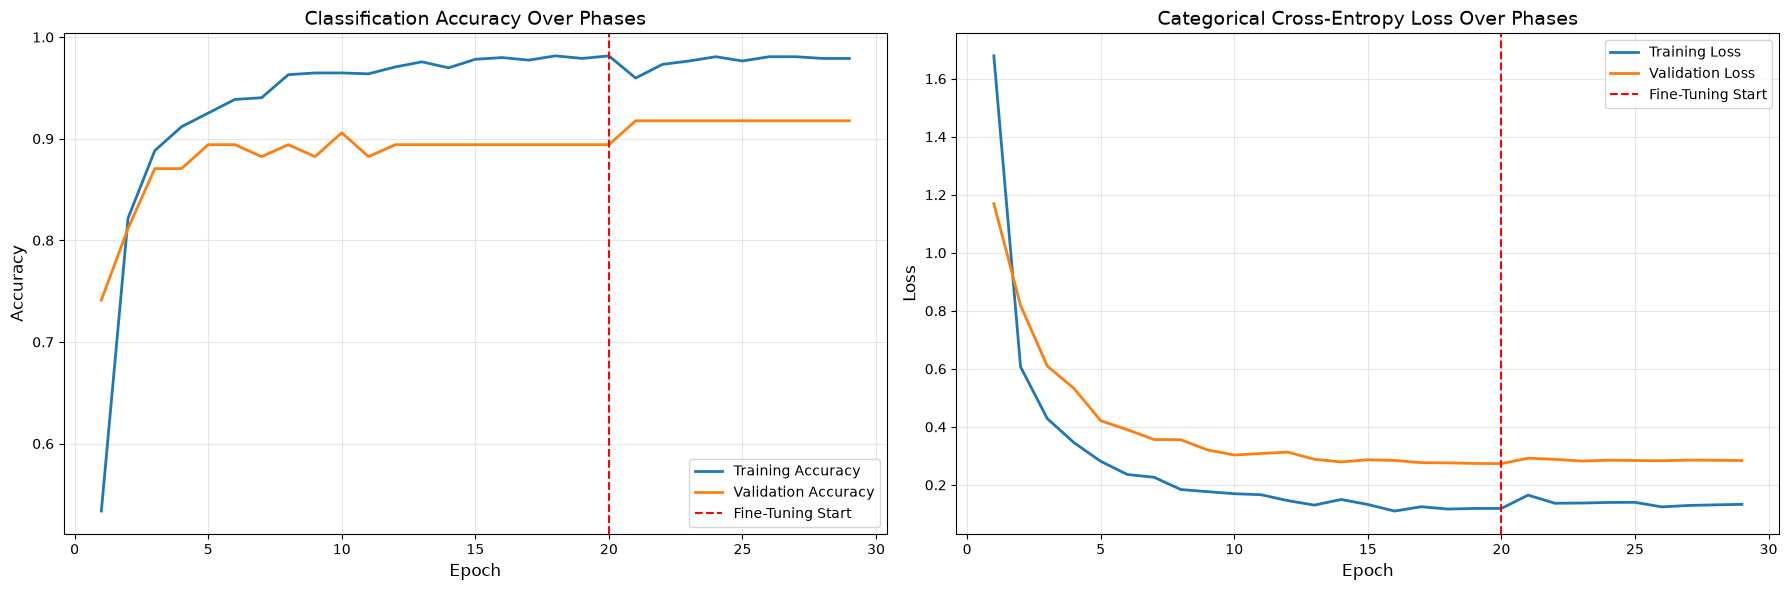

In [12]:
# 8: Complete Learning Curves Visualization (Phase 1 + Phase 2)

def plot_unified_training_dynamics(h1, h2, save_dir: Path):
    """
    Concatenates and visualizes loss and accuracy curves across both training phases.
    """
    acc = h1.history["accuracy"] + h2.history["accuracy"]
    val_acc = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    loss = h1.history["loss"] + h2.history["loss"]
    val_loss = h1.history["val_loss"] + h2.history["val_loss"]

    p1_len = len(h1.history["loss"])
    epochs_range = range(1, len(loss) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Accuracy Dynamics
    axes[0].plot(epochs_range, acc, label="Training Accuracy", color="#1f77b4", linewidth=2)
    axes[0].plot(epochs_range, val_acc, label="Validation Accuracy", color="#ff7f0e", linewidth=2)
    axes[0].axvline(x=p1_len, color="red", linestyle="--", label="Fine-Tuning Start")
    axes[0].set_title("Classification Accuracy Over Phases", fontsize=14)
    axes[0].set_xlabel("Epoch", fontsize=12)
    axes[0].set_ylabel("Accuracy", fontsize=12)
    axes[0].legend(loc="lower right")
    axes[0].grid(alpha=0.3)

    # Loss Dynamics
    axes[1].plot(epochs_range, loss, label="Training Loss", color="#1f77b4", linewidth=2)
    axes[1].plot(epochs_range, val_loss, label="Validation Loss", color="#ff7f0e", linewidth=2)
    axes[1].axvline(x=p1_len, color="red", linestyle="--", label="Fine-Tuning Start")
    axes[1].set_title("Categorical Cross-Entropy Loss Over Phases", fontsize=14)
    axes[1].set_xlabel("Epoch", fontsize=12)
    axes[1].set_ylabel("Loss", fontsize=12)
    axes[1].legend(loc="upper right")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_dir / "learning_dynamics_curve.png", dpi=300)
    plt.show()

plot_unified_training_dynamics(history_phase1, history_phase2, PLOTS_DIR)


In [13]:
# 9: Unbiased Generalization Evaluation on Isolated Test Split

# Load the definitive optimal fine-tuned model checkpoint
best_production_model = keras.models.load_model(phase2_checkpoint_path)

print("[INFO] Evaluating best model against isolated, previously unseen Test Set...")
test_loss, test_acc, test_top3_acc = best_production_model.evaluate(test_ds, verbose=1)

print("\n" + "="*50)
print(f"  TEST SET EVALUATION METRICS")
print("="*50)
print(f"  Test Cross-Entropy Loss: {test_loss:.4f}")
print(f"  Test Accuracy (Top-1):    {test_acc * 100:.2f}%")
print(f"  Test Accuracy (Top-3):    {test_top3_acc * 100:.2f}%")
print("="*50)


[INFO] Evaluating best model against isolated, previously unseen Test Set...
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 714ms/step - accuracy: 0.8824 - loss: 0.4593 - top_3_accuracy: 0.9647

  TEST SET EVALUATION METRICS
  Test Cross-Entropy Loss: 0.4593
  Test Accuracy (Top-1):    88.24%
  Test Accuracy (Top-3):    96.47%


3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step 

--- Detailed Classification Report ---
              precision    recall  f1-score   support

    bluebell     1.0000    0.8000    0.8889         5
   buttercup     0.8333    1.0000    0.9091         5
  colts_foot     1.0000    1.0000    1.0000         5
     cowslip     0.0000    0.0000    0.0000         5
      crocus     0.8333    1.0000    0.9091         5
    daffodil     0.5556    1.0000    0.7143         5
       daisy     1.0000    1.0000    1.0000         5
   dandelion     1.0000    1.0000    1.0000         5
  fritillary     1.0000    1.0000    1.0000         5
        iris     0.7143    1.0000    0.8333         5
 lily_valley     1.0000    0.2000    0.3333         5
       pansy     1.0000    1.0000    1.0000         5
    snowdrop     0.7143    1.0000    0.8333         5
   sunflower     1.0000    1.0000    1.0000         5
   tigerlily     1.0000    1.0000    1.0000         5
       tulip     1.0000    1.0000    1.0000         5
  w

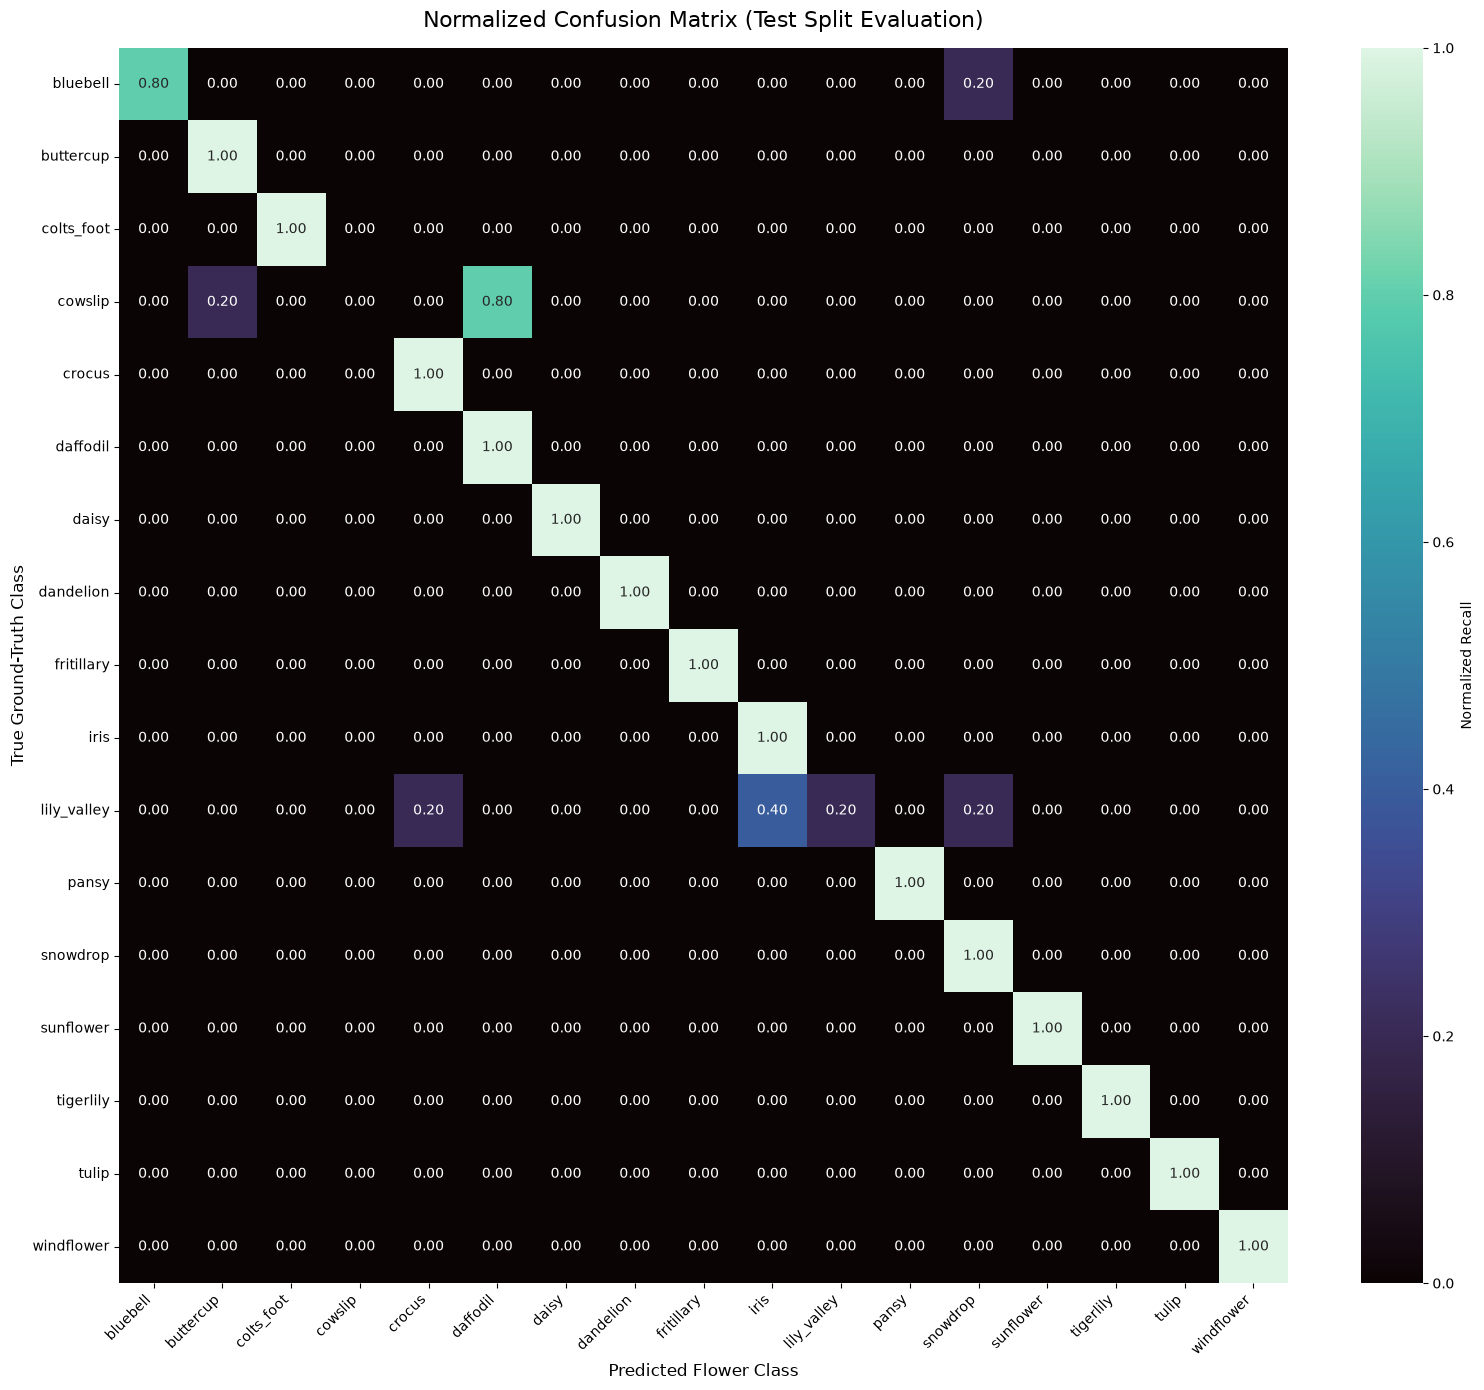

In [14]:
# 10: In-Depth Diagnostic Reports & Normalized Confusion Matrix

# Extract ground-truth arrays and model posterior probabilities across the test set
y_true_test = np.concatenate([labels.numpy() for _, labels in test_ds])
y_probs_test = best_production_model.predict(test_ds, verbose=1)
y_pred_test = np.argmax(y_probs_test, axis=1)

# Generate detailed Sklearn classification report
test_classification_rep = classification_report(
    y_true_test,
    y_pred_test,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
)

print("\n--- Detailed Classification Report ---")
print(test_classification_rep)

# Persist metrics to disk for portfolio and auditing
with open(METRICS_DIR / "final_test_classification_report.txt", "w", encoding="utf-8") as f:
    f.write(test_classification_rep)

# Compute Normalized Confusion Matrix
conf_mat = confusion_matrix(y_true_test, y_pred_test, normalize="true")

plt.figure(figsize=(16, 14))
sns.heatmap(
    conf_mat,
    annot=True,
    fmt=".2f",
    cmap="mako",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar_kws={"label": "Normalized Recall"}
)
plt.title("Normalized Confusion Matrix (Test Split Evaluation)", fontsize=16, pad=15)
plt.xlabel("Predicted Flower Class", fontsize=12)
plt.ylabel("True Ground-Truth Class", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(PLOTS_DIR / "normalized_test_confusion_matrix.png", dpi=300)
plt.show()


In [15]:
# Cell 11: Production Artifact Export & Inference Predictor Function

import json
from pathlib import Path
import numpy as np
from PIL import Image


# 1. Select the final production model

# Prefer the best production model created in the previous cells.
# If it does not exist, use the current trained model.
if "best_production_model" in globals():
    production_model = best_production_model
    print("[INFO] Using: best_production_model")
elif "model" in globals():
    production_model = model
    print("[WARNING] best_production_model was not found.")
    print("[INFO] Using the current model instead.")
else:
    raise NameError(
        "Neither 'best_production_model' nor 'model' exists. "
        "Please run the model-training cells first."
    )


# 2. Create a production-artifacts directory

PRODUCTION_DIR = Path(CHECKPOINT_DIR) / "production_artifacts"
PRODUCTION_DIR.mkdir(parents=True, exist_ok=True)

print(f"[INFO] Production artifacts directory: {PRODUCTION_DIR}")


# 3. Export the trained model

PRODUCTION_MODEL_PATH = (
    PRODUCTION_DIR / "flower_efficientnetb0_production.keras"
)

production_model.save(PRODUCTION_MODEL_PATH)

print(
    f"[INFO] Production model saved to:\n"
    f"       {PRODUCTION_MODEL_PATH}"
)


# 4. Export class names

CLASS_NAMES_PATH = PRODUCTION_DIR / "class_names.json"

class_names_serializable = [
    str(class_name)
    for class_name in CLASS_NAMES
]

with open(CLASS_NAMES_PATH, "w", encoding="utf-8") as f:
    json.dump(
        class_names_serializable,
        f,
        ensure_ascii=False,
        indent=4
    )

print(
    f"[INFO] Class names saved to:\n"
    f"       {CLASS_NAMES_PATH}"
)


# 5. Export model metadata

MODEL_METADATA_PATH = PRODUCTION_DIR / "model_metadata.json"

model_metadata = {
    "model_name": "Flower EfficientNetB0 Classifier",
    "architecture": "EfficientNetB0",
    "num_classes": int(len(CLASS_NAMES)),
    "class_names": class_names_serializable,
    "input_shape": [
        int(dimension)
        for dimension in INPUT_SHAPE
    ],
    "output_activation": "softmax",
    "artifact_format": "Keras .keras",
    "purpose": "17-class flower image classification"
}

with open(MODEL_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(
        model_metadata,
        f,
        ensure_ascii=False,
        indent=4
    )

print(
    f"[INFO] Model metadata saved to:\n"
    f"       {MODEL_METADATA_PATH}"
)


# 6. Define the inference predictor function

def predict_flower(
    image_path: str,
    trained_model=production_model,
    class_names=CLASS_NAMES,
    top_k: int = 3
):
    """
    Predicts the flower class for a single image.

    Parameters
    ----------
    image_path : str
        Path to the input image.

    trained_model : keras.Model
        Trained flower classification model.

    class_names : list
        List of class names in the same order used during training.

    top_k : int
        Number of top predictions to return.

    Returns
    -------
    dict
        Prediction result containing the predicted class,
        confidence, and top-k predictions.
    """

    image_path = Path(image_path)

    if not image_path.is_file():
        raise FileNotFoundError(
            f"Image file not found:\n{image_path}"
        )

    if top_k < 1:
        raise ValueError("top_k must be at least 1.")

    top_k = min(top_k, len(class_names))

    # Read target image size from INPUT_SHAPE
    target_height = int(INPUT_SHAPE[0])
    target_width = int(INPUT_SHAPE[1])

    # Load and preprocess image
    image = Image.open(image_path).convert("RGB")
    image = image.resize(
        (target_width, target_height)
    )

    image_array = np.asarray(
        image,
        dtype=np.float32
    )

    # Add batch dimension: (H, W, C) -> (1, H, W, C)
    image_batch = np.expand_dims(
        image_array,
        axis=0
    )

    # Generate prediction probabilities
    probabilities = trained_model.predict(
        image_batch,
        verbose=0
    )[0]

    # Select top-k predictions
    top_indices = np.argsort(
        probabilities
    )[::-1][:top_k]

    top_predictions = []

    for index in top_indices:
        top_predictions.append(
            {
                "class_name": str(class_names[index]),
                "class_index": int(index),
                "confidence": float(probabilities[index])
            }
        )

    best_prediction = top_predictions[0]

    result = {
        "image_path": str(image_path),
        "predicted_class": best_prediction["class_name"],
        "confidence": best_prediction["confidence"],
        "top_k_predictions": top_predictions
    }

    return result


# 7. Test the predictor function with one image

print("\n[INFO] Production artifact export completed successfully.")
print("[INFO] Predictor function 'predict_flower' is ready.")

print("\nAvailable production files:")
for artifact_path in sorted(PRODUCTION_DIR.iterdir()):
    print(f" - {artifact_path.name}")


[INFO] Using: best_production_model
[INFO] Production artifacts directory: artifacts\checkpoints\production_artifacts
[INFO] Production model saved to:
       artifacts\checkpoints\production_artifacts\flower_efficientnetb0_production.keras
[INFO] Class names saved to:
       artifacts\checkpoints\production_artifacts\class_names.json
[INFO] Model metadata saved to:
       artifacts\checkpoints\production_artifacts\model_metadata.json

[INFO] Production artifact export completed successfully.
[INFO] Predictor function 'predict_flower' is ready.

Available production files:
 - class_names.json
 - flower_efficientnetb0_production.keras
 - model_metadata.json


In [16]:
sample_image_path = (
    Path("17_flowers")
    / "splits"
    / "test"
    / "bluebell"
    / "image_0243.jpg"
)

prediction_result = predict_flower(
    image_path=sample_image_path,
    top_k=3
)

print(json.dumps(
    prediction_result,
    ensure_ascii=False,
    indent=4
))


{
    "image_path": "17_flowers\\splits\\test\\bluebell\\image_0243.jpg",
    "predicted_class": "bluebell",
    "confidence": 0.7715178728103638,
    "top_k_predictions": [
        {
            "class_name": "bluebell",
            "class_index": 0,
            "confidence": 0.7715178728103638
        },
        {
            "class_name": "crocus",
            "class_index": 4,
            "confidence": 0.15571308135986328
        },
        {
            "class_name": "pansy",
            "class_index": 11,
            "confidence": 0.033116333186626434
        }
    ]
}
